In [9]:
%pip install vaderSentiment
%pip install datasets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
from datasets import load_dataset

# Load goEmotions Dataset and get Sentiment Labels
goEmotionsDataset = load_dataset('go_emotions')
sentimentLabels = goEmotionsDataset['train'].features['labels'].feature.names

In [11]:
sentimentMap = {
  "positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
  "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust", "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
  "neutral": ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

In [12]:
# 3. Helper function to find the "True" bucket for a specific comment
def get_true_sentiment(row):
    """
    Looks at the true labels (e.g., [27]) and maps them to 'neutral', 'positive', or 'negative'.
    """
    label_ids = row['labels']
    current_emotions = [sentimentLabels[i] for i in label_ids]

    counts = {'positive': 0, 'negative': 0, 'neutral': 0}
    for emo in current_emotions:
        if emo in sentimentMap['positive']: counts['positive'] += 1
        elif emo in sentimentMap['negative']: counts['negative'] += 1
        elif emo in sentimentMap['neutral']: counts['neutral'] += 1

    return max(counts, key=counts.get)

print("Generating Ground Truth labels for Test Set...")
goEmotionsDataset['test'] = goEmotionsDataset['test'].map(lambda x: {'sentiment_bucket': get_true_sentiment(x)})
print("Done!")

Generating Ground Truth labels for Test Set...
Done!


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Init VADER analyzer
analyzer = SentimentIntensityAnalyzer()

In [14]:
# Update goEmotions dataset with VADER sentiment prediction

def get_vader_prediction(row):
    text = row['text']

    # Get VADER scores
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']

    # Standard VADER thresholds
    if compound >= 0.05:
        prediction = "positive"
    elif compound <= -0.05:
        prediction = "negative"
    else:
        prediction = "neutral"

    return {"vader_prediction": prediction}

print("Running VADER on Test Set...")
goEmotionsDataset['test'] = goEmotionsDataset['test'].map(get_vader_prediction)
print("VADER predictions complete.")

Running VADER on Test Set...
VADER predictions complete.


In [15]:
import time

# Latency report: time VADER inference on the full test set (same format as CNN)
test_texts = goEmotionsDataset['test']['text']
num_samples = len(test_texts)

print("Starting VADER Evaluation on Test Set...")
start_time = time.time()
for text in test_texts:
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        _ = "positive"
    elif compound <= -0.05:
        _ = "negative"
    else:
        _ = "neutral"
end_time = time.time()
total_time = end_time - start_time

print(f"Processed {num_samples} samples in {total_time:.2f} seconds.")
print(f"VADER Average Latency: {(total_time / num_samples) * 1000:.2f} milliseconds per post.")

Starting VADER Evaluation on Test Set...
Processed 5427 samples in 0.14 seconds.
VADER Average Latency: 0.03 milliseconds per post.


In [16]:
from sklearn.metrics import classification_report

y_true = goEmotionsDataset['test']['sentiment_bucket']
y_pred = goEmotionsDataset['test']['vader_prediction']

print("VADER Final Evaluation (Test Set - 5,427 Samples):")
print("-" * 60)
print(classification_report(
    y_true,
    y_pred,
    target_names=['negative', 'neutral', 'positive'] # Order matters for sklearn sometimes, but labels handles it
))

VADER Final Evaluation (Test Set - 5,427 Samples):
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.49      0.66      0.57      1182
     neutral       0.72      0.40      0.51      2147
    positive       0.65      0.82      0.72      2098

    accuracy                           0.62      5427
   macro avg       0.62      0.63      0.60      5427
weighted avg       0.64      0.62      0.61      5427



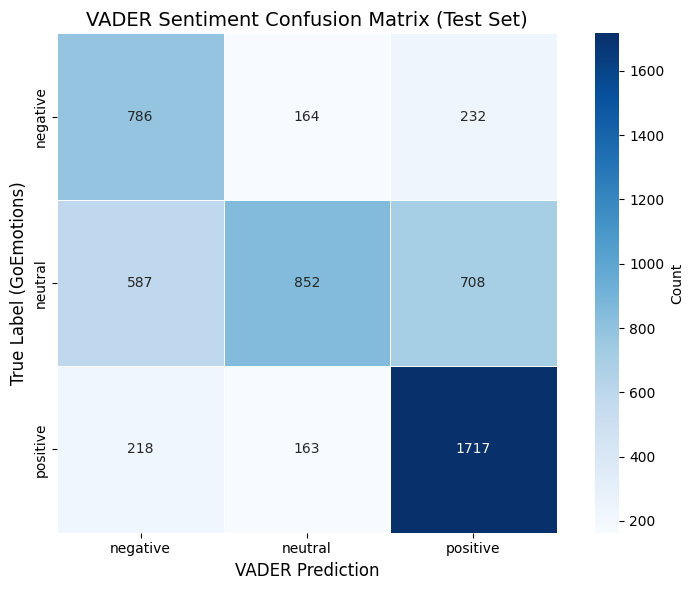

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels_order = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            cbar_kws={'label': 'Count'}, square=True, linewidths=0.5)
plt.xlabel('VADER Prediction', fontsize=12)
plt.ylabel('True Label (GoEmotions)', fontsize=12)
plt.title('VADER Sentiment Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()